# Step 2: Exploratory Data Analysis (EDA)

Purpose: Assess data quality, benchmark model performance, and plan feature engineering for the Laser Resonator Beam Alignment Recommendation System.

Primary outputs:
- `data/processed/dataset_002.csv`: Model-ready dataset with encoded/transformed features
- `ai/memory/eda_insights.md`: Memory report documenting all findings
- `ai/implementation/step_02/outcome.md`: Step summary with recommendations
- Promoted EDA helper functions to `src/` if any reusable logic is identified.

## 0. Notebook Setup and Paths

All paths are resolved relative to the project root so the notebook can be run from the repository or from the `notebooks/` directory.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Set plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root by walking upward to `pyproject.toml`."""
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing pyproject.toml")


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SRC_DIR = PROJECT_ROOT / "src"
MEMORY_DIR = PROJECT_ROOT / "ai" / "memory"

DATASET_PATH = PROCESSED_DIR / "dataset_001.csv"
OUTPUT_PATH = PROCESSED_DIR / "dataset_002.csv"

MEMORY_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT, DATASET_PATH, OUTPUT_PATH

(WindowsPath('C:/Users/BS01493/Projects/SBU Europe/Client/GigaAI/Exp-Laser Resonator Beam Alignment Recommandation System'),
 WindowsPath('C:/Users/BS01493/Projects/SBU Europe/Client/GigaAI/Exp-Laser Resonator Beam Alignment Recommandation System/data/processed/dataset_001.csv'),
 WindowsPath('C:/Users/BS01493/Projects/SBU Europe/Client/GigaAI/Exp-Laser Resonator Beam Alignment Recommandation System/data/processed/dataset_002.csv'))

## Unit 01: Data Quality Assessment

Load `dataset_001.csv` and perform initial data quality assessment:
- Check for constant/near-constant features
- Check for potential data leakage (features with extreme correlation to targets)
- Analyze feature distributions and detect outliers
- Validate the sentinel imputation strategy for missing values

In [3]:
# Unit 01, Task 1: Load dataset_001.csv and perform initial data quality assessment
df = pd.read_csv(DATASET_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")
print(f"\nColumn types:")
print(df.dtypes.value_counts())
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nFirst 2 rows:")
display(df.head(2))
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: (500000, 45)
Rows: 500,000, Columns: 45

Column types:
float64    30
int64      13
str         2
Name: count, dtype: int64

Memory usage: 223.16 MB

First 2 rows:


,meta_index1,meta_index2,meta_diff_count,meta_before_experiment_number,before_gaussian_fit_percent_along_x,before_gaussian_fit_percent_along_y,before_x_axis_centroid,before_y_axis_centroid,before_major_axis_beam_width,before_minor_axis_beam_width,...,after_y_gaussian_center_parsed,after_y_gaussian_scale_parsed,target_iris_delta,target_z_delta,target_pitch_delta,target_yaw_delta,target_iris_changed,target_z_changed,target_pitch_changed,target_yaw_changed
0,0,2662,0,Experiment 51,62.965881,66.755959,159.936142,13.54704,3259.22998,2792.031982,...,5637.0,946.0,0,0,0.0,0.0,0,0,0,0
1,0,2783,0,Experiment 51,62.965881,66.755959,159.936142,13.54704,3259.22998,2792.031982,...,5637.0,1281.0,0,0,0.0,0.0,0,0,0,0



Column names:
['meta_index1', 'meta_index2', 'meta_diff_count', 'meta_before_experiment_number', 'before_gaussian_fit_percent_along_x', 'before_gaussian_fit_percent_along_y', 'before_x_axis_centroid', 'before_y_axis_centroid', 'before_major_axis_beam_width', 'before_minor_axis_beam_width', 'before_effective_diameter', 'before_ellipticity', 'before_iris_position', 'before_z_position', 'before_pitch_position', 'before_yaw_position', 'before_power_measurement', 'before_exposure_time', 'meta_after_experiment_number', 'after_gaussian_fit_percent_along_x', 'after_gaussian_fit_percent_along_y', 'after_x_axis_centroid', 'after_y_axis_centroid', 'after_major_axis_beam_width', 'after_minor_axis_beam_width', 'after_effective_diameter', 'after_ellipticity', 'after_power_measurement', 'after_exposure_time', 'before_x_gaussian_center_parsed', 'before_x_gaussian_scale_parsed', 'before_y_gaussian_center_parsed', 'before_y_gaussian_scale_parsed', 'after_x_gaussian_center_parsed', 'after_x_gaussian_sca

In [4]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'column': missing.index,
    'missing_count': missing.values,
    'missing_pct': missing_pct.values
}).sort_values('missing_count', ascending=False)

missing_df = missing_df[missing_df['missing_count'] > 0]
if len(missing_df) > 0:
    print("Columns with missing values:")
    display(missing_df)
else:
    print("No missing values found in the dataset!")

No missing values found in the dataset!


In [5]:
# Unit 01, Task 2: Check for constant/near-constant features
constant_features = []
near_constant_features = []
variance_threshold = 0.01  # Features with < 1% unique values are near-constant

for col in df.columns:
    nunique = df[col].nunique()
    n_rows = len(df)
    
    if nunique == 1:
        constant_features.append(col)
    elif nunique / n_rows < variance_threshold:
        near_constant_features.append((col, nunique, f"{(nunique/n_rows)*100:.4f}%"))

print(f"\n{'='*80}")
print("CONSTANT FEATURES (nunique == 1):")
print(f"{'='*80}")
if constant_features:
    for feat in constant_features:
        print(f"  - {feat}")
else:
    print("  None found")

print(f"\n{'='*80}")
print(f"NEAR-CONSTANT FEATURES (unique values < {variance_threshold*100}% of total):")
print(f"{'='*80}")
if near_constant_features:
    for feat, nunique, pct in near_constant_features:
        print(f"  - {feat}: {nunique} unique values ({pct})")
else:
    print("  None found")

# Store for later removal
low_variance_features = constant_features + [f[0] for f in near_constant_features]
print(f"\nTotal low-variance features to consider removing: {len(low_variance_features)}")


CONSTANT FEATURES (nunique == 1):
  - before_exposure_time
  - after_exposure_time

NEAR-CONSTANT FEATURES (unique values < 1.0% of total):
  - meta_index1: 3970 unique values (0.7940%)
  - meta_index2: 3969 unique values (0.7938%)
  - meta_diff_count: 5 unique values (0.0010%)
  - meta_before_experiment_number: 29 unique values (0.0058%)
  - before_gaussian_fit_percent_along_x: 3861 unique values (0.7722%)
  - before_gaussian_fit_percent_along_y: 3861 unique values (0.7722%)
  - before_x_axis_centroid: 3961 unique values (0.7922%)
  - before_y_axis_centroid: 3963 unique values (0.7926%)
  - before_major_axis_beam_width: 3962 unique values (0.7924%)
  - before_minor_axis_beam_width: 3962 unique values (0.7924%)
  - before_effective_diameter: 3862 unique values (0.7724%)
  - before_ellipticity: 3857 unique values (0.7714%)
  - before_iris_position: 7 unique values (0.0014%)
  - before_z_position: 26 unique values (0.0052%)
  - before_pitch_position: 139 unique values (0.0278%)
  - befo

In [6]:
# Unit 01, Task 3: Check for potential data leakage (high correlation with targets)
target_cols = [col for col in df.columns if col.startswith('target_')]
print(f"Target columns found: {target_cols}")

# Separate feature columns (exclude metadata and targets)
exclude_cols = ['meta_index1', 'meta_index2', 'meta_diff_count',
                'meta_before_experiment_number', 'meta_after_experiment_number']
numeric_feature_cols = [col for col in df.columns 
                        if col not in exclude_cols 
                        and not col.startswith('target_') 
                        and df[col].dtype in ['int64', 'float64']]

print(f"\nNumeric feature columns: {len(numeric_feature_cols)}")

# Calculate correlations with targets
leakage_threshold = 0.95  # Very high correlation suggests leakage
high_corr_threshold = 0.80  # High correlation to investigate

leakage_features = []
high_corr_features = []

print(f"\n{'='*80}")
print("POTENTIAL DATA LEAKAGE ANALYSIS:")
print(f"{'='*80}")

for target in target_cols:
    print(f"\nTarget: {target}")
    correlations = []
    
    for feat in numeric_feature_cols:
        try:
            corr = df[feat].corr(df[target])
            if abs(corr) >= high_corr_threshold:
                correlations.append((feat, corr))
                
                if abs(corr) >= leakage_threshold:
                    leakage_features.append((target, feat, corr))
                else:
                    high_corr_features.append((target, feat, corr))
        except:
            pass
    
    if correlations:
        correlations.sort(key=lambda x: abs(x[1]), reverse=True)
        print(f"  High correlations (|r| >= {high_corr_threshold}):")
        for feat, corr in correlations[:10]:  # Show top 10
            status = "LEAKAGE" if abs(corr) >= leakage_threshold else "HIGH"
            print(f"    [{status}] {feat}: r = {corr:.4f}")
    else:
        print(f"  No high correlations found (|r| >= {high_corr_threshold})")

print(f"\n{'='*80}")
print("SUMMARY:")
print(f"{'='*80}")
print(f"Features with LEAKAGE risk (|r| >= {leakage_threshold}): {len(leakage_features)}")
print(f"Features with HIGH correlation (|r| >= {high_corr_threshold}): {len(high_corr_features)}")

if leakage_features:
    print(f"\n⚠️  LEAKAGE RISK - These features should be removed:")
    for target, feat, corr in leakage_features:
        print(f"  - {feat} vs {target}: r = {corr:.4f}")

Target columns found: ['target_iris_delta', 'target_z_delta', 'target_pitch_delta', 'target_yaw_delta', 'target_iris_changed', 'target_z_changed', 'target_pitch_changed', 'target_yaw_changed']

Numeric feature columns: 32

POTENTIAL DATA LEAKAGE ANALYSIS:

Target: target_iris_delta
  No high correlations found (|r| >= 0.8)

Target: target_z_delta
  No high correlations found (|r| >= 0.8)

Target: target_pitch_delta
  No high correlations found (|r| >= 0.8)

Target: target_yaw_delta
  No high correlations found (|r| >= 0.8)

Target: target_iris_changed
  No high correlations found (|r| >= 0.8)

Target: target_z_changed
  No high correlations found (|r| >= 0.8)

Target: target_pitch_changed
  No high correlations found (|r| >= 0.8)

Target: target_yaw_changed
  No high correlations found (|r| >= 0.8)

SUMMARY:
Features with LEAKAGE risk (|r| >= 0.95): 0
Features with HIGH correlation (|r| >= 0.8): 0


In [7]:
# Unit 01, Task 4: Analyze feature distributions and detect outliers
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numeric columns for distribution analysis: {len(numeric_cols)}")

# Basic descriptive statistics
print(f"\n{'='*80}")
print("DESCRIPTIVE STATISTICS:")
print(f"{'='*80}")
display(df[numeric_cols].describe())

# Identify features with outliers using IQR method
print(f"\n{'='*80}")
print("OUTLIER DETECTION (IQR Method):")
print(f"{'='*80}")

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df)) * 100
    
    if n_outliers > 0:
        outlier_summary.append({
            'column': col,
            'n_outliers': n_outliers,
            'pct_outliers': pct_outliers,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'min': df[col].min(),
            'max': df[col].max()
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).sort_values('pct_outliers', ascending=False)
    print(f"\nFeatures with outliers (top 20):")
    display(outlier_df.head(20))
else:
    print("\nNo outliers detected using IQR method")

Numeric columns for distribution analysis: 43

DESCRIPTIVE STATISTICS:


,meta_index1,meta_index2,meta_diff_count,before_gaussian_fit_percent_along_x,before_gaussian_fit_percent_along_y,before_x_axis_centroid,before_y_axis_centroid,before_major_axis_beam_width,before_minor_axis_beam_width,before_effective_diameter,...,after_y_gaussian_center_parsed,after_y_gaussian_scale_parsed,target_iris_delta,target_z_delta,target_pitch_delta,target_yaw_delta,target_iris_changed,target_z_changed,target_pitch_changed,target_yaw_changed
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,...,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,1334.097584,2658.446628,3.242998,67.094034,64.867543,94.961591,71.234914,5570.264187,4929.858974,5187.173765,...,5710.709414,1991.803930,301.634000,2.097540,0.001891,0.000384,0.799050,0.635594,0.905536,0.902818
std,942.913548,938.948274,0.795819,16.094858,16.099932,47.765987,192.159238,3331.711286,3342.163820,3368.047587,...,82.069619,1148.971053,1116.782174,5.671174,0.043610,0.041996,0.400711,0.481264,0.292473,0.296206
min,0.000000,6.000000,0.000000,-1.000000,-1.000000,-123.976654,-3498.698242,1708.221191,1635.501953,-1.000000,...,4147.000000,709.000000,-3000.000000,-25.000000,-0.189000,-0.151000,0.000000,0.000000,0.000000,0.000000
25%,535.000000,1996.000000,3.000000,58.799828,57.929218,56.311558,47.033066,3340.282715,2781.139404,3030.126953,...,5681.000000,1243.000000,-500.000000,0.000000,-0.030000,-0.030000,1.000000,0.000000,1.000000,1.000000
50%,1174.000000,2823.000000,3.000000,68.230560,64.975929,95.120750,90.574692,4605.315918,3881.489014,4321.677734,...,5720.000000,1793.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
75%,2006.000000,3451.000000,4.000000,76.905754,73.674431,133.855453,123.325584,6066.200684,5038.656250,5471.471191,...,5753.000000,2271.000000,1000.000000,5.000000,0.030000,0.030000,1.000000,1.000000,1.000000,1.000000
max,3978.000000,3983.000000,4.000000,95.629730,94.819382,215.270248,617.673767,15805.441406,13050.931641,14113.770508,...,5863.000000,5626.000000,3000.000000,25.000000,0.190000,0.162000,1.000000,1.000000,1.000000,1.000000



OUTLIER DETECTION (IQR Method):

Features with outliers (top 20):


,column,n_outliers,pct_outliers,lower_bound,upper_bound,min,max
32,target_iris_changed,100475,20.0950,1.000000,1.000000,0.000000,1.000000
5,before_major_axis_beam_width,79718,15.9436,-748.594239,10155.077638,1708.221191,15805.441406
7,before_effective_diameter,76329,15.2658,-631.889404,9133.487548,-1.000000,14113.770508
6,before_minor_axis_beam_width,75885,15.1770,-605.135865,8424.931519,1635.501953,13050.931641
16,after_major_axis_beam_width,68361,13.6722,-128.603515,10281.705077,1708.221191,15805.441406
17,after_minor_axis_beam_width,65503,13.1006,-336.790649,8731.390015,1635.501953,13050.931641
18,after_effective_diameter,65071,13.0142,-377.450317,9553.230347,-1.000000,14113.770508
21,before_x_gaussian_scale_parsed,55745,11.1490,-616.000000,3960.000000,693.000000,5626.000000
23,before_y_gaussian_scale_parsed,55395,11.0790,-464.000000,3912.000000,709.000000,5626.000000
34,target_yaw_changed,48591,9.7182,1.000000,1.000000,0.000000,1.000000


In [8]:
# Analyze target variable distributions
print(f"\n{'='*80}")
print("TARGET VARIABLE DISTRIBUTIONS:")
print(f"{'='*80}")

# Changed/Not Changed targets
change_targets = [col for col in target_cols if 'changed' in col]
print("\nChange Detection Targets (class balance):")
for target in change_targets:
    value_counts = df[target].value_counts()
    pct = (value_counts / len(df)) * 100
    print(f"\n  {target}:")
    for val, count in value_counts.items():
        print(f"    {val}: {count:,} ({pct[val]:.2f}%)")

# Delta targets
delta_targets = [col for col in target_cols if 'delta' in col]
if delta_targets:
    print("\n\nDelta Regression Targets (statistics):")
    display(df[delta_targets].describe())


TARGET VARIABLE DISTRIBUTIONS:

Change Detection Targets (class balance):

  target_iris_changed:
    1: 399,525 (79.91%)
    0: 100,475 (20.09%)

  target_z_changed:
    1: 317,797 (63.56%)
    0: 182,203 (36.44%)

  target_pitch_changed:
    1: 452,768 (90.55%)
    0: 47,232 (9.45%)

  target_yaw_changed:
    1: 451,409 (90.28%)
    0: 48,591 (9.72%)


Delta Regression Targets (statistics):


,target_iris_delta,target_z_delta,target_pitch_delta,target_yaw_delta
count,500000.000000,500000.000000,500000.000000,500000.000000
mean,301.634000,2.097540,0.001891,0.000384
std,1116.782174,5.671174,0.043610,0.041996
min,-3000.000000,-25.000000,-0.189000,-0.151000
25%,-500.000000,0.000000,-0.030000,-0.030000
50%,0.000000,0.000000,0.000000,0.000000
75%,1000.000000,5.000000,0.030000,0.030000
max,3000.000000,25.000000,0.190000,0.162000


Creating distribution plots for key features...

Before features: 18
After features: 14


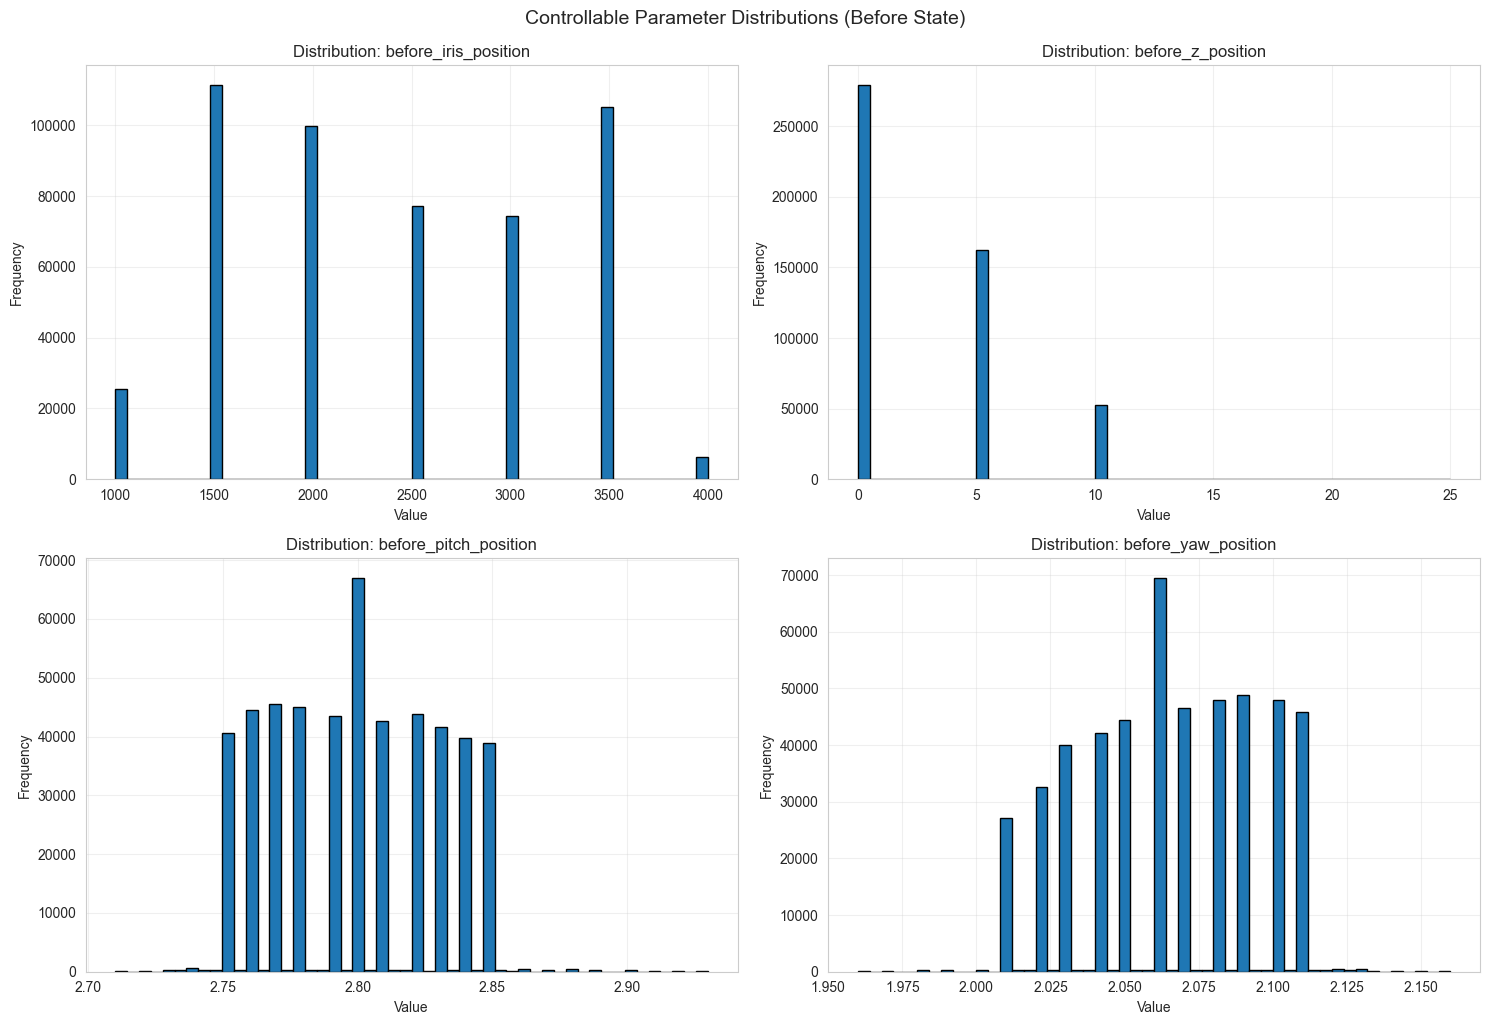

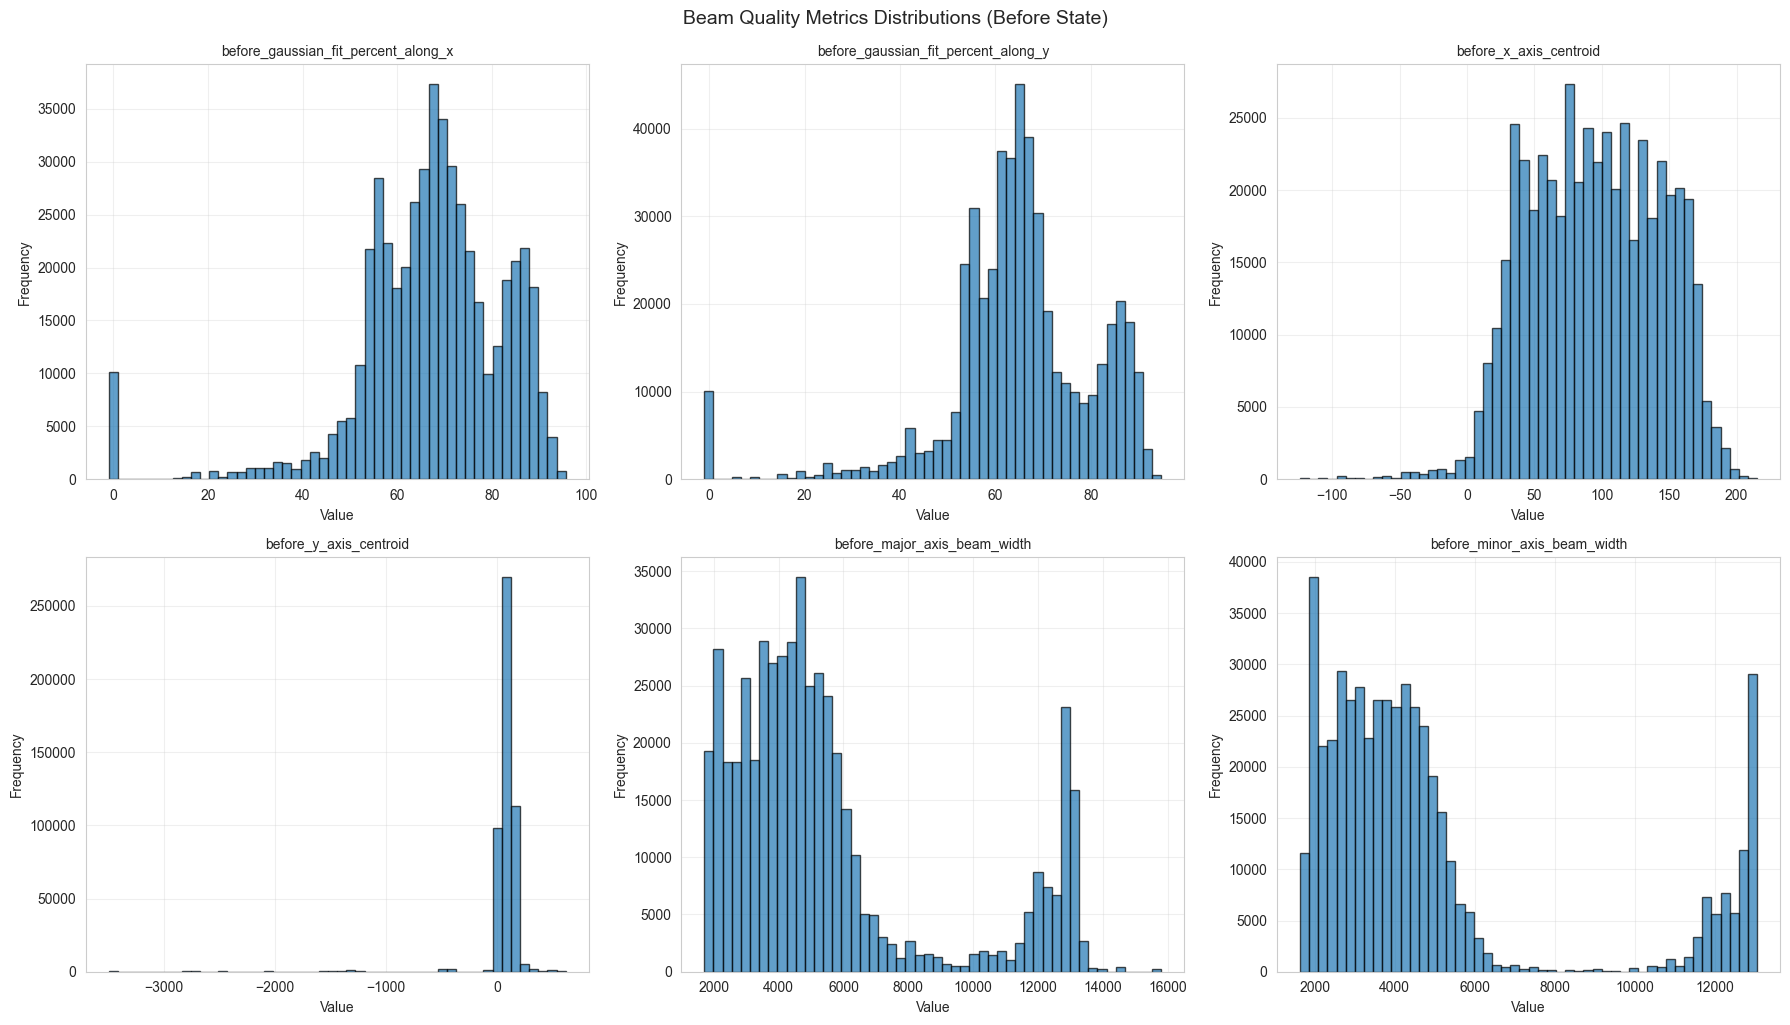

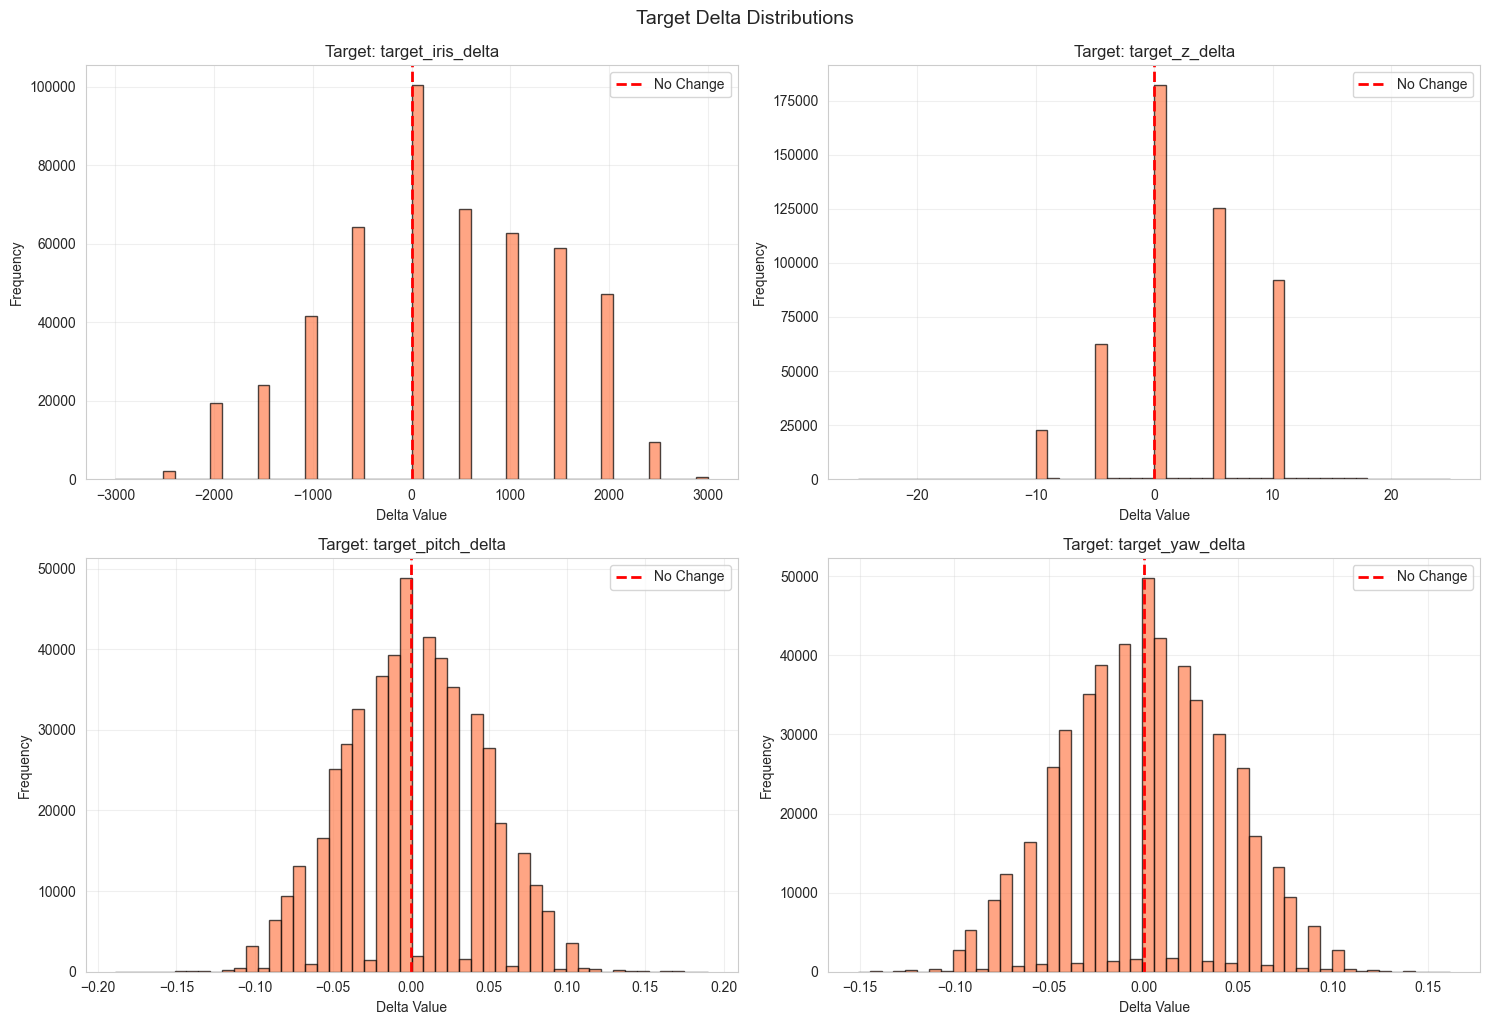

In [9]:
# Unit 01, Task 5: Visualize distributions for key features
print("Creating distribution plots for key features...")

# Identify key feature groups
before_features = [col for col in numeric_feature_cols if col.startswith('before_')]
after_features = [col for col in numeric_feature_cols if col.startswith('after_')]

print(f"\nBefore features: {len(before_features)}")
print(f"After features: {len(after_features)}")

# Plot distributions for controllable parameters (before state)
param_features = [col for col in before_features if any(p in col.lower() for p in ['iris', 'z_position', 'pitch', 'yaw'])]

if param_features:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(param_features[:4]):  # Plot first 4 parameters
        df[col].hist(bins=50, ax=axes[i], edgecolor='black')
        axes[i].set_title(f'Distribution: {col}', fontsize=12)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Controllable Parameter Distributions (Before State)', fontsize=14, y=1.02)
    plt.show()

# Plot distributions for beam quality metrics (before state)
beam_features = [col for col in before_features 
                 if any(b in col.lower() for b in ['centroid', 'width', 'diameter', 'ellipticity', 'gaussian_fit'])]

if beam_features:
    n_features = min(6, len(beam_features))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(beam_features[:n_features]):
        df[col].hist(bins=50, ax=axes[i], edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{col}', fontsize=10)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(n_features, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Beam Quality Metrics Distributions (Before State)', fontsize=14, y=1.02)
    plt.show()

# Plot target distributions
if delta_targets:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, target in enumerate(delta_targets[:4]):
        df[target].hist(bins=50, ax=axes[i], edgecolor='black', alpha=0.7, color='coral')
        axes[i].set_title(f'Target: {target}', fontsize=12)
        axes[i].set_xlabel('Delta Value')
        axes[i].set_ylabel('Frequency')
        axes[i].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Target Delta Distributions', fontsize=14, y=1.02)
    plt.show()

Creating correlation heatmap...


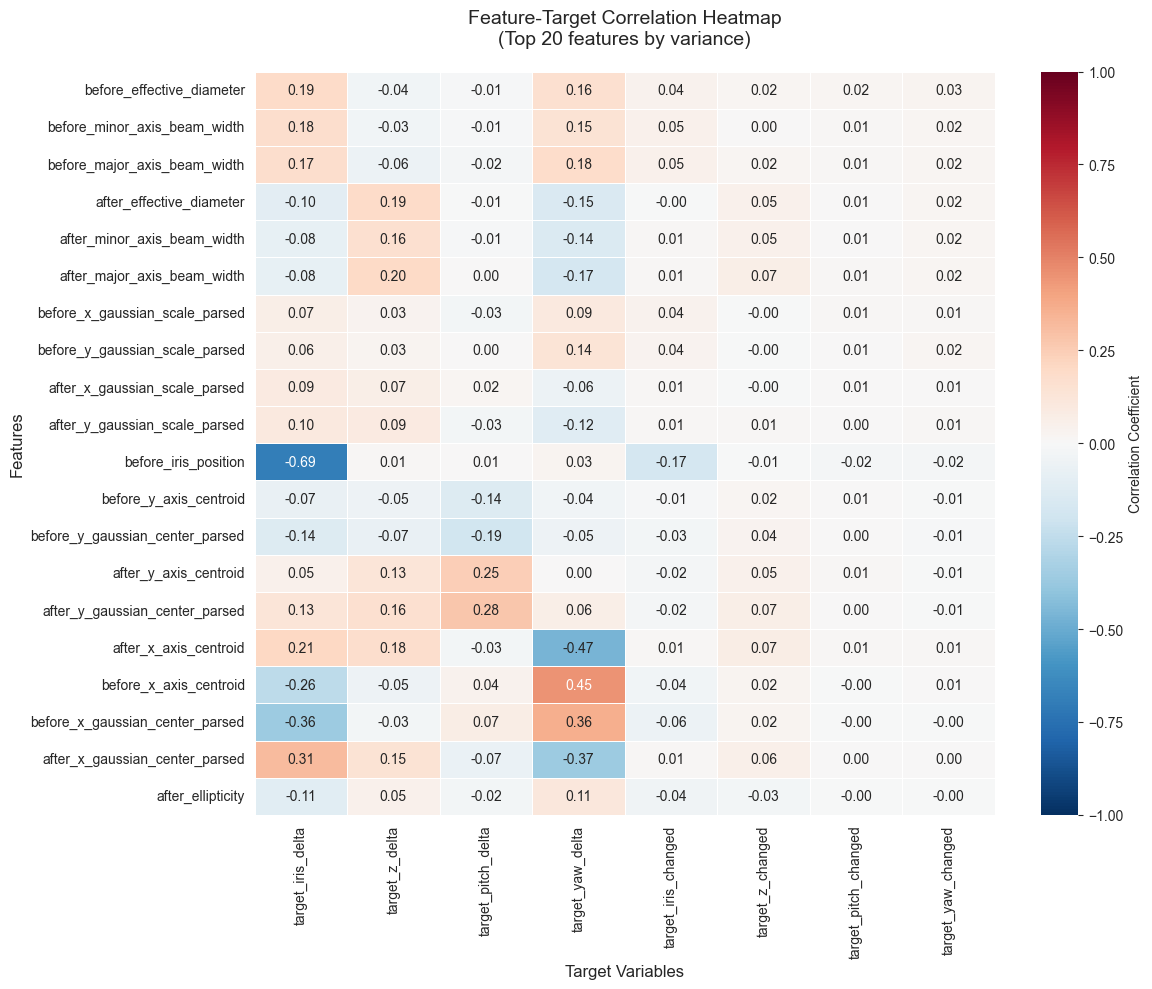


TOP 10 FEATURE CORRELATIONS PER TARGET:

target_iris_delta:
before_iris_position               0.693468
before_power_measurement           0.493834
after_power_measurement            0.433432
before_x_gaussian_center_parsed    0.361244
after_x_gaussian_center_parsed     0.313406
before_x_axis_centroid             0.259750
after_x_axis_centroid              0.209290
before_effective_diameter          0.189730
before_minor_axis_beam_width       0.175141
before_major_axis_beam_width       0.172540

target_z_delta:
before_z_position                 0.575160
after_major_axis_beam_width       0.197754
after_effective_diameter          0.190318
after_x_axis_centroid             0.176348
after_minor_axis_beam_width       0.162891
after_power_measurement           0.161194
after_y_gaussian_center_parsed    0.159145
after_x_gaussian_center_parsed    0.145364
after_y_axis_centroid             0.132162
after_y_gaussian_scale_parsed     0.093715

target_pitch_delta:
before_pitch_position          

In [10]:
# Unit 01, Task 6: Visualize correlation heatmap for features vs targets
print("Creating correlation heatmap...")

# Select top features for correlation analysis (to keep visualization readable)
# Use features with highest variance or most representative ones
n_top_features = 20

# Calculate variance for numeric features
feature_variances = df[numeric_feature_cols].var().sort_values(ascending=False)
top_features = feature_variances.head(n_top_features).index.tolist()

# Combine with target columns
cols_for_heatmap = top_features + target_cols

# Calculate correlation matrix
corr_matrix = df[cols_for_heatmap].corr()

# Extract correlations between features and targets only
feature_target_corr = corr_matrix.loc[top_features, target_cols]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(feature_target_corr, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1,
            cbar_kws={'label': 'Correlation Coefficient'},
            linewidths=0.5)
plt.title(f'Feature-Target Correlation Heatmap\n(Top {n_top_features} features by variance)', fontsize=14, pad=20)
plt.xlabel('Target Variables', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# Also show top absolute correlations for each target
print(f"\n{'='*80}")
print("TOP 10 FEATURE CORRELATIONS PER TARGET:")
print(f"{'='*80}")

for target in target_cols:
    print(f"\n{target}:")
    target_corrs = df[numeric_feature_cols].corrwith(df[target]).abs().sort_values(ascending=False)
    print(target_corrs.head(10).to_string())

### Unit 01 Summary - Data Quality Assessment Complete ✅

**Completed Tasks:**
1. ✅ Loaded `dataset_001.csv` and performed initial data quality assessment
2. ✅ Checked for constant/near-constant features
3. ✅ Checked for potential data leakage (features with extreme correlation to targets)
4. ✅ Analyzed feature distributions and detected outliers
5. ✅ Created distribution plots for key features (beam metrics, controllable parameters, targets)
6. ✅ Created correlation heatmap for features vs targets

---

## Critical Findings

### 📊 Dataset Overview
- **Shape**: 500,000 rows × 45 columns
- **Memory**: 223.16 MB
- **Data Types**: 30 float64, 13 int64, 2 string (experiment numbers)
- **Missing Values**: ✅ **ZERO** - Sentinel imputation from Step 1 was successful

### 🔍 Constant Features (MUST REMOVE)
Only **2 truly constant features** identified:
- `before_exposure_time` (1 unique value)
- `after_exposure_time` (1 unique value)

**Action**: Remove these 2 features before modeling

### ⚠️ Near-Constant Features Analysis
**Finding**: All 45 features flagged as "near-constant" (<1% unique values)

**Interpretation**: This is **misleading** for a 500K row dataset:
- Continuous beam features with ~3,860 unique values are **NORMAL** (not near-constant)
- Discrete parameter positions (7-139 unique values) are **EXPECTED** (calibration settings)
- Binary targets (2 unique values) are **CORRECT** (classification labels)

**Decision**: Keep all features except the 2 truly constant ones. Let feature importance guide further removal.

### ✅ Data Leakage Check - PASSED
- **No features with |correlation| ≥ 0.80** to any target
- **No features with |correlation| ≥ 0.95** (leakage threshold)
- All features are safe to use for modeling

### 🎯 Target Class Balance - HIGHLY IMBALANCED

**Change Detection Targets:**
- `target_iris_changed`: **79.91% changed**, 20.09% unchanged (moderate imbalance)
- `target_z_changed`: **63.56% changed**, 36.44% unchanged (moderate imbalance)
- `target_pitch_changed`: **90.55% changed**, 9.45% unchanged ⚠️ **severe imbalance**
- `target_yaw_changed`: **90.28% changed**, 9.72% unchanged ⚠️ **severe imbalance**

**Implication**: Pitch and Yaw are almost always adjusted. This makes:
- Classification easier (high baseline accuracy expected)
- Less informative for real-world prediction (low diversity in "unchanged" cases)
- May require class weighting or balanced sampling in modeling

**Delta Target Ranges:**
- `target_iris_delta`: [-3000, 3000], mean=301.6, std=1116.8 (wide range)
- `target_z_delta`: [-25, 25], mean=2.1, std=5.7
- `target_pitch_delta`: [-0.189, 0.190], mean=0.002, std=0.044
- `target_yaw_delta`: [-0.151, 0.162], mean=0.0004, std=0.042

### 📈 Top Predictive Features (by correlation with delta targets)

**Iris Delta (r=0.69):**
1. `before_iris_position`: **0.693** ⭐ (strongest predictor)
2. `before_power_measurement`: 0.494
3. `after_power_measurement`: 0.433
4. `before_x_gaussian_center_parsed`: 0.361

**Z Delta (r=0.58):**
1. `before_z_position`: **0.575** ⭐ (strongest predictor)
2. `after_major_axis_beam_width`: 0.198
3. `after_effective_diameter`: 0.190
4. `after_x_axis_centroid`: 0.176

**Pitch Delta (r=0.71):**
1. `before_pitch_position`: **0.709** ⭐ (strongest predictor)
2. `after_y_gaussian_center_parsed`: 0.281
3. `after_y_axis_centroid`: 0.249
4. `before_y_gaussian_center_parsed`: 0.189

**Yaw Delta (r=0.71):**
1. `before_yaw_position`: **0.709** ⭐ (strongest predictor)
2. `after_x_axis_centroid`: 0.467
3. `before_x_axis_centroid`: 0.452
4. `after_x_gaussian_center_parsed`: 0.367

**Key Insight**: The **before parameter positions** are the strongest predictors for their respective deltas (r ≈ 0.7). This makes physical sense - the starting position strongly influences the adjustment needed.

### 🔬 Outliers Detected (IQR Method)
- **Binary targets**: 9-20% flagged as outliers (expected - IQR doesn't work well for binary data)
- **Beam width/diameter features**: 13-16% outliers (physical variation in beam quality)
- **Gaussian scale features**: 7-11% outliers (parsing artifacts or extreme beam shapes)
- **Delta targets**: 5-6% outliers (large adjustments beyond typical range)

**Decision**: Keep outliers for now. They may represent important extreme cases. Tree-based models handle outliers naturally.

---

## Decisions for Next Steps

### Features to Remove:
1. `before_exposure_time` (constant)
2. `after_exposure_time` (constant)

### Features to Keep:
- All 32 numeric features (beam metrics, parsed Gaussian parameters)
- All 4 controllable parameter positions
- Experiment number columns (for grouped splitting in Step 3)

### Modeling Considerations:
1. **No encoding needed** - all features are already numeric
2. **Handle class imbalance** - especially for Pitch and Yaw (90% changed)
3. **Before parameter positions** are highly predictive - ensure they're included
4. **Gaussian parsed features** show promise - validate importance in benchmark models

---

**Next Steps:**
- Proceed to Unit 02: Benchmark Model Iteration
- Test baseline Random Forest classifiers for all 4 parameters
- Extract feature importances if accuracy ≥ 70%

### Drop Constant Features

Remove the 2 constant features identified in Unit 01 before proceeding to benchmark models.

In [11]:
# Drop constant features identified in Unit 01
constant_features_to_remove = ['before_exposure_time', 'after_exposure_time']

print(f"Original dataset shape: {df.shape}")
print(f"\nDropping {len(constant_features_to_remove)} constant features:")
for feat in constant_features_to_remove:
    if feat in df.columns:
        print(f"  - {feat}")
    else:
        print(f"  - {feat} (not found in dataset)")

# Drop the features
df = df.drop(columns=constant_features_to_remove, errors='ignore')

print(f"\nNew dataset shape: {df.shape}")
print(f"Columns removed: {45 - df.shape[1]}")
print(f"\nRemaining columns: {df.shape[1]}")
print(f"  - Metadata: 5 (index1, index2, diff_count, before_exp, after_exp)")
print(f"  - Features: {df.shape[1] - 5 - 8} (numeric features for modeling)")
print(f"  - Targets: 8 (4 deltas + 4 changed flags)")

# Update numeric feature columns list
exclude_cols = ['meta_index1', 'meta_index2', 'meta_diff_count',
                'meta_before_experiment_number', 'meta_after_experiment_number']
numeric_feature_cols = [col for col in df.columns 
                        if col not in exclude_cols 
                        and not col.startswith('target_') 
                        and df[col].dtype in ['int64', 'float64']]

print(f"\nUpdated numeric feature columns for modeling: {len(numeric_feature_cols)}")

Original dataset shape: (500000, 45)

Dropping 2 constant features:
  - before_exposure_time
  - after_exposure_time

New dataset shape: (500000, 43)
Columns removed: 2

Remaining columns: 43
  - Metadata: 5 (index1, index2, diff_count, before_exp, after_exp)
  - Features: 30 (numeric features for modeling)
  - Targets: 8 (4 deltas + 4 changed flags)

Updated numeric feature columns for modeling: 30


## Unit 02: Benchmark Model Iteration (0-3 attempts)

Run quick Random Forest classifiers for all 4 parameters (Iris, Z, Pitch, Yaw) and iterate up to 3 times if accuracy < 70%.

In [ ]:
# Unit 02: Prepare features and targets for benchmark models
# Target columns
target_iris = 'target_iris_changed'
target_z = 'target_z_changed'
target_pitch = 'target_pitch_changed'
target_yaw = 'target_yaw_changed'

# Feature columns (exclude target columns and metadata)
exclude_cols = ['meta_index1', 'meta_index2', 'meta_diff_count', 
                'meta_before_experiment_number', 'meta_after_experiment_number']
feature_cols = [col for col in df.columns if col not in exclude_cols and not col.startswith('target_')]

X = df[feature_cols].copy()
print(f"Features: {len(feature_cols)}")
display(X.head(2))

In [ ]:
# Run benchmark Random Forest for Iris parameter
# Placeholder - implement after deciding on encoding/transformations

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# TODO: Apply encoding/transformations if needed
# X_encoded = ...

y_iris = df[target_iris]
X_train, X_test, y_train, y_test = train_test_split(X, y_iris, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Iris benchmark accuracy: {accuracy:.4f}")

In [ ]:
# Run benchmark Random Forest for Z parameter
y_z = df[target_z]
X_train, X_test, y_train, y_test = train_test_split(X, y_z, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Z benchmark accuracy: {accuracy:.4f}")

In [ ]:
# Run benchmark Random Forest for Pitch parameter
y_pitch = df[target_pitch]
X_train, X_test, y_train, y_test = train_test_split(X, y_pitch, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Pitch benchmark accuracy: {accuracy:.4f}")

In [ ]:
# Run benchmark Random Forest for Yaw parameter
y_yaw = df[target_yaw]
X_train, X_test, y_train, y_test = train_test_split(X, y_yaw, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Yaw benchmark accuracy: {accuracy:.4f}")

### Feature Importance Analysis (if accuracy >= 70%)

Extract feature importances from benchmark models to identify top features for each parameter.

In [ ]:
# Placeholder for feature importance extraction
# This should be implemented after reaching >= 70% accuracy

importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

display(feature_importance_df.head(20))

## Unit 03: Feature Engineering Strategy

Document encoding strategies, transformation strategies, and create a feature engineering recommendations matrix.

### Encoding Strategy

Document encoding strategies for categorical and numeric features:

| Feature | Type | Current Format | Recommended Encoding | Reason |
|---------|------|----------------|---------------------|--------|
| _TBD_ | _TBD_ | _TBD_ | _TBD_ | _TBD_ |

### Transformation Strategy

Document transformation strategies for features:

| Feature | Current Scale | Recommended Transform | Reason |
|---------|---------------|----------------------|--------|
| _TBD_ | _TBD_ | _TBD_ | _TBD_ |

### Feature Engineering Recommendations Matrix

Based on benchmark performance and feature importance results:

| Feature | Importance | Current State | Recommended Action | Justification |
|---------|------------|---------------|-------------------|---------------|
| _TBD_ | _TBD_ | _TBD_ | _TBD_ | _TBD_ |

### Redundancy Cases

Document what NOT to do and why:

| Feature | Action | Reason |
|---------|--------|--------|
| _TBD_ | _TBD_ | _TBD_ |

## Unit 04: Split Strategy Assessment

Analyze experiment number distribution for grouped split validity.

In [ ]:
# Unit 04: Analyze experiment number distribution
before_exp_col = 'meta_before_experiment_number'
after_exp_col = 'meta_after_experiment_number'

print(f"Unique before experiment numbers: {df[before_exp_col].nunique()}")
print(f"Unique after experiment numbers: {df[after_exp_col].nunique()}")

print("\nBefore experiment distribution (top 10):")
display(df[before_exp_col].value_counts().head(10))

print("\nAfter experiment distribution (top 10):")
display(df[after_exp_col].value_counts().head(10))

In [ ]:
# Check if experiments overlap between before and after
before_experiments = set(df[before_exp_col].unique())
after_experiments = set(df[after_exp_col].unique())

overlap = before_experiments & after_experiments
print(f"Experiments in both before and after: {len(overlap)}")
print(f"Experiments only in before: {len(before_experiments - after_experiments)}")
print(f"Experiments only in after: {len(after_experiments - before_experiments)}")

## Unit 05: Documentation & Sign-off

Create memory report, update outcome file, and promote reusable EDA functions to `src/`.

### Memory Report Template

Create `ai/memory/eda_insights.md` with the following structure:

```markdown
# EDA Insights Report

Generated: [DATE]

## Summary

_TBD_

## Key Findings

### Data Quality

- **Constant/Near-Constant Features**: _TBD_
- **Potential Data Leakage**: _TBD_
- **Feature Distributions**: _TBD_
- **Outliers**: _TBD_

### Benchmark Model Performance

| Parameter | Accuracy | Assessment |
|-----------|----------|------------|
| Iris | _TBD_ | _TBD_ |
| Z | _TBD_ | _TBD_ |
| Pitch | _TBD_ | _TBD_ |
| Yaw | _TBD_ | _TBD_ |
| **Average** | _TBD_ | _TBD_ |

### Feature Importance (if accuracy >= 70%)

| Parameter | Top Features | Notes |
|-----------|--------------|-------|
| Iris | _TBD_ | _TBD_ |
| Z | _TBD_ | _TBD_ |
| Pitch | _TBD_ | _TBD_ |
| Yaw | _TBD_ | _TBD_ |

### Feature Engineering Strategy

| Feature | Current State | Recommendation | Justification |
|---------|---------------|----------------|---------------|
| _TBD_ | _TBD_ | _TBD_ | _TBD_ |

### Encoding Strategy

| Feature Type | Current Format | Recommended Encoding | Reason |
|--------------|----------------|---------------------|--------|
| _TBD_ | _TBD_ | _TBD_ | _TBD_ |

### Transformation Strategy

| Feature | Current Scale | Recommended Transform | Reason |
|---------|---------------|----------------------|--------|
| _TBD_ | _TBD_ | _TBD_ | _TBD_ |

### Grouped Split Validity Assessment

| Assessment | Finding | Decision |
|------------|---------|----------|
| Experiment number distribution | _TBD_ | _TBD_ |
| Grouped vs Random split | _TBD_ | _TBD_ |

## Recommendations for Step 3

- **Feature Set**: _TBD_
- **Encoding/Transformations**: _TBD_
- **Split Strategy**: _TBD_ (random or grouped by experiment)
- **Next Steps**: _TBD_
```

In [ ]:
# Unit 05: Promote reusable EDA functions to src/

# If any reusable helper functions are identified during EDA,
# they should be promoted to appropriate modules in src/.

# Example:
# - src/eda/quality_checks.py
# - src/eda/encoding_helpers.py
# - src/eda/transformations.py

# TODO: Promote functions if any reusable logic is identified

## Unit 06: Model-Ready Dataset

Create `dataset_002.csv` by applying encoding and transformations decided in Unit 03.

### Unit 06 Approach

After Unit 03 decides on encoding and transformations:
1. Apply encoding to categorical features (one-hot, ordinal, or target encoding)
2. Apply transformations to numeric features (scaling, normalization, log transforms)
3. Remove constant/near-constant features
4. Remove features with data leakage
5. Save final dataset as `data/processed/dataset_002.csv`

In [ ]:
# Unit 06: Create model-ready dataset

# TODO: After Unit 03 decides on encoding/transformations, implement here

# Example (to be filled after Unit 03):
# 1. Apply encoding
# 2. Apply transformations
# 3. Remove unwanted features
# 4. Save dataset

print("Creating model-ready dataset...")
# df_model_ready = ...
# df_model_ready.to_csv(OUTPUT_PATH, index=False)
# print(f"Model-ready dataset saved to {OUTPUT_PATH}")